In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
import pickle

with open('/content/drive/MyDrive/team_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train     = data['X_train']
y_train     = data['y_train']
X_val       = data['X_val']
y_val       = data['y_val']
X_test      = data['X_test']
y_test      = data['y_test']
tokenizer   = data['tokenizer']
le          = data['label_encoder']
NUM_CLASSES = data['NUM_CLASSES']
MAX_LEN     = data['MAX_LEN']
MAX_WORDS   = data['MAX_WORDS']

print("X_train:", X_train.shape)
print("Classes:", data['classes'])

X_train: (382284, 200)
Classes: ['anxiety', 'depression', 'loneliness', 'normal', 'suicidal']


In [12]:
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    GRU(64),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/3
747/747 ━━━━━━━━━━━━━━━━━━━━ 815s 1s/step - accuracy: 0.2838 - loss: 1.5183 - val_accuracy: 0.4685 - val_loss: 1.2219
Epoch 2/3
747/747 ━━━━━━━━━━━━━━━━━━━━ 775s 1s/step - accuracy: 0.5912 - loss: 1.0184 - val_accuracy: 0.6304 - val_loss: 0.9467
Epoch 3/3
747/747 ━━━━━━━━━━━━━━━━━━━━ 808s 1s/step - accuracy: 0.6537 - loss: 0.8950 - val_accuracy: 0.6449 - val_loss: 0.9183


In [14]:
from sklearn.metrics import classification_report

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Loss:     0.9246
Test Accuracy: 0.6392
1494/1494 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step
              precision    recall  f1-score   support

     anxiety       0.78      0.79      0.79      9828
  depression       0.51      0.40      0.45      9766
  loneliness       0.71      0.77      0.74      9188
      normal       0.57      0.52      0.55      9504
    suicidal       0.59      0.72      0.65      9500

    accuracy                           0.64     47786
   macro avg       0.63      0.64      0.63     47786
weighted avg       0.63      0.64      0.63     47786



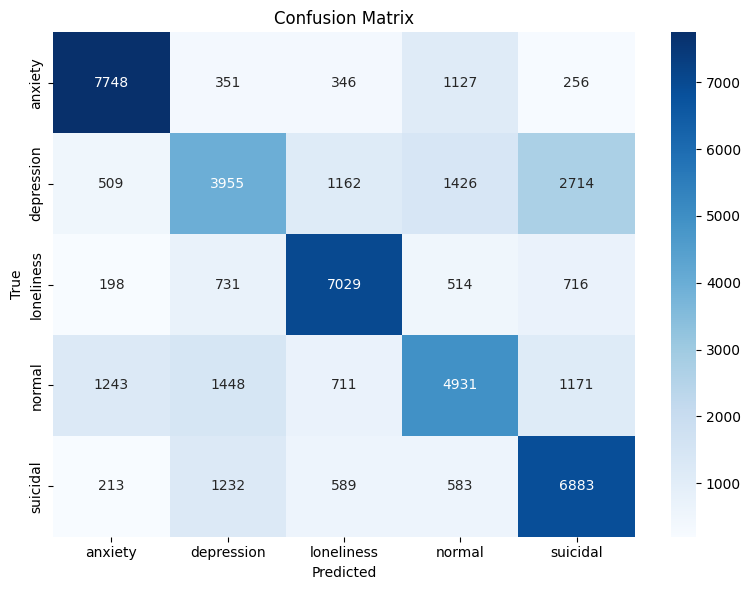

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

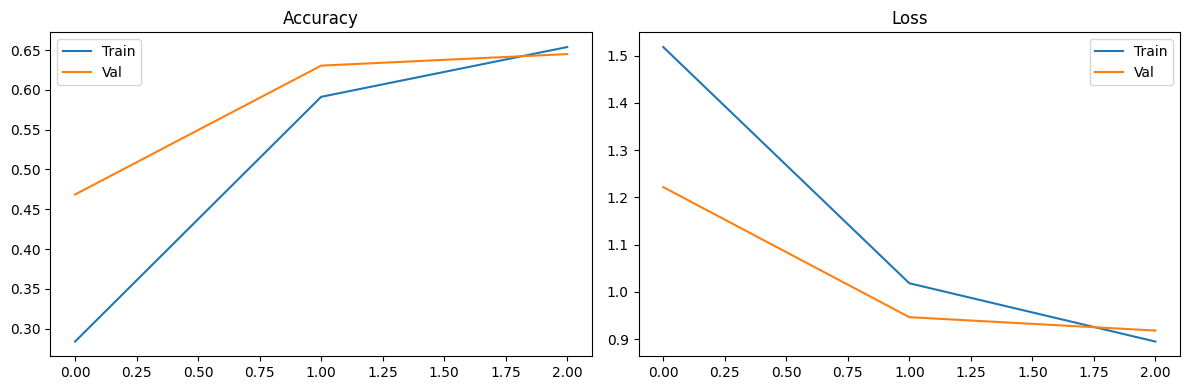

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
model.save('/content/drive/MyDrive/gru_model.h5')
print("Model saved!")

Model saved!


In [18]:
import pickle
with open('/content/drive/MyDrive/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved!")

Tokenizer saved!
